In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

cm = 1/2.54
font = 8
font_label = 10
plt.rcParams['font.family'] = 'Helvetica'

colors = ['darkblue', 'aquamarine', 'darkorange']
cmap = LinearSegmentedColormap.from_list('mycmap', colors)
amount = 100
color_list = cmap(np.linspace(0, 1, amount))

In [57]:
def load_data(work_dir, nr_chains):
    sasa = np.genfromtxt((work_dir + 'sasa.xvg'), usecols=(1), skip_header=24, unpack=True)
    re_ave = 0
    rg_ave = 0
    dist_ave = 0
    
    counter1 = 0
    counter2 = 0
    for chain1 in range(0, nr_chains):
        re, rg = np.genfromtxt((work_dir + 'polystat/' + str(chain1) + '.xvg'), usecols=(1, 2), skip_header=28, unpack=True)
        re_ave += re
        rg_ave += rg
        counter1 += 1
        for chain2 in range(0, nr_chains):
            dist = np.genfromtxt((work_dir + 'pairdist/Chain' + str(chain1) + '/' + str(chain1) + '_' + str(chain2) + '.xvg'),
                                 usecols=(1), skip_header=24, unpack=True)
            if chain1 == chain2:
                continue
            else:
                dist_ave += dist
                counter2 += 1

    data_array = np.zeros((len(sasa), 4))
    data_array[:, 0] = re_ave/counter1
    data_array[:, 1] = rg_ave/counter1
    data_array[:, 2] = dist_ave/counter2
    data_array[:, 3] = sasa
    return data_array

CG_dir = '/Users/oskarsvensson/Science/FILES/ARTICLES/Hst1_self/MARTINI/'
CG_data = load_data(CG_dir, 32)

In [58]:
def data_reduction(data_array, alpha1, alpha2):
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(data_array)
    pca = PCA(n_components=2, random_state=44)
    pca_data = pca.fit_transform(scaled_data)
    print(pca.explained_variance_ratio_)
    print(pca.explained_variance_ratio_.sum()) 
    
    counter = 0
    landscape = np.zeros_like(pca_data)
    for entry in pca_data:
        landscape[counter, 0] = int((entry[0] - np.min(pca_data[:, 0]))*alpha1)
        landscape[counter, 1] = int((entry[1] - np.min(pca_data[:, 1]))*alpha2)
        counter += 1

    x = np.expand_dims((np.arange(np.min(landscape[:, 0]), np.max(landscape[:, 0]))), axis=0)
    y = np.expand_dims((np.arange(np.min(landscape[:, 1]), np.max(landscape[:, 1]))), axis=1)
    X, Y = np.meshgrid(x, y)
    Z = np.zeros_like(X)
    counter1 = 0
    for (x1, y1) in zip(X, Y):
        counter2 = 0
        for (x2, y2) in zip(x1, y1):
            for entry in landscape:
                if (x2 == entry[0]) and (y2 == entry[1]):
                    Z[counter1, counter2] += 1
            counter2 += 1
        counter1 += 1
    return landscape, X, Y, Z

CG_landscape, CG_X, CG_Y, CG_Z = data_reduction(CG_data, 3, 3)

[0.52901026 0.33504835]
0.8640586082915913


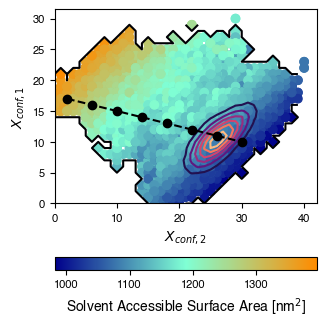

In [69]:
fig, ax = plt.subplots(ncols=1, nrows=1, figsize=((8*cm), (8*cm)), constrained_layout=True)
CG = ax.scatter(CG_landscape[:, 0], CG_landscape[:, 1], c=CG_data[:, 3], cmap=cmap)
ax.tick_params(labelsize=font)
cbar = fig.colorbar(CG, ax=ax, orientation='horizontal')
cbar.ax.tick_params(labelsize=font)
cbar.set_label('Solvent Accessible Surface Area [nm$^{2}$]', fontsize=font_label)
ax.contour(CG_X, CG_Y, CG_Z, cmap='magma')
CG_path_x = [2, 6, 10, 14, 18, 22, 26, 30]
CG_path_y = [17, 16, 15, 14, 13, 12, 11, 10]
ax.plot(CG_path_x, CG_path_y, color='black', marker='o', linestyle='--')
ax.set_ylabel('$X_{conf, 1}$', fontsize=font_label)
ax.set_xlabel('$X_{conf, 2}$', fontsize=font_label)
plt.savefig('/Users/oskarsvensson/Desktop/Current/Hst1_asso/New_new_figures/Landscape.png', dpi=1000)

In [65]:
def traj_decomp(path, landscape, path_x, path_y):
    for (x, y) in zip(path_x, path_y):
        frames = []
        counter = 1
        for point in landscape:
            if (x == point[0]) and (y == point[1]):
                frames.append(counter)
            counter += 1

        with open((path + str(x) + '_' + str(y) + '.ndx'), 'w') as save:
            save.write('[ path ]' + '\n')
            counter = 1
            for frame in frames:
                if counter == 6:
                    save.write('    ' + str(frame) + '\n')
                    counter = 0
                else:
                    save.write('    ' + str(frame))
                    counter += 1
            save.write('\n')

path = '/Users/oskarsvensson/Science/FILES/ARTICLES/Hst1_self/MARTINI/'
traj_decomp(path, CG_landscape, CG_path_x, CG_path_y)